# Visualizing and choosing the number of clusters in clustering

In [1]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

from yellowbrick.cluster.elbow import kelbow_visualizer
from yellowbrick.cluster import silhouette_visualizer

plt.rcParams['font.family'] = 'DejaVu Sans'

## Make blobs for testing
- https://scikit-learn.org/stable/datasets/sample_generators.html

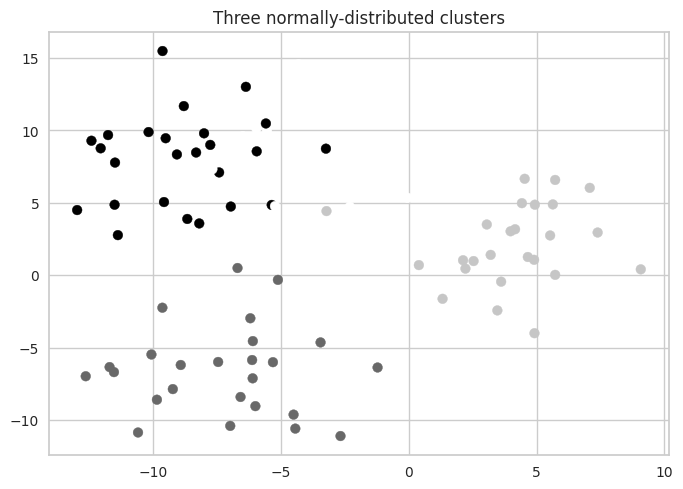

In [2]:
X, y = make_blobs(centers=4, cluster_std=3, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Three normally-distributed clusters")
plt.show()

## Build elbow and silhouette plot

### Loop trough n clusters and build plots with matplotlib

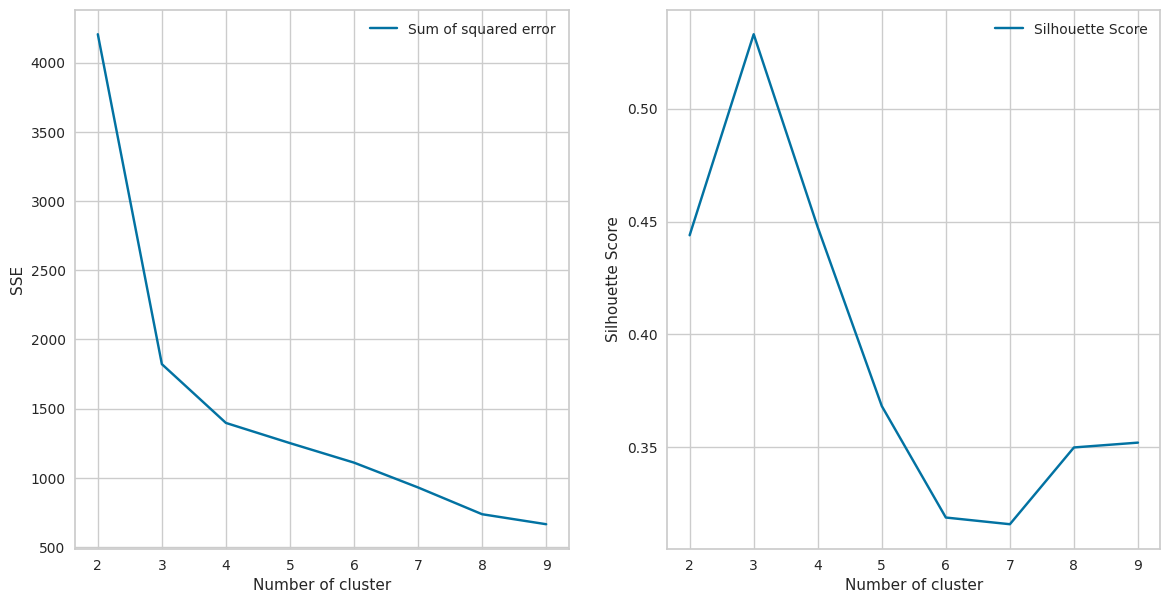

In [3]:
range_n_clusters = range(2, 10)
elbow = []
ss = []
for n_clusters in range_n_clusters:
   #iterating through cluster sizes
   clusterer = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
   cluster_labels = clusterer.fit_predict(X)
   #Finding the average silhouette score
   silhouette_avg = silhouette_score(X, cluster_labels)
   ss.append(silhouette_avg)
   #Finding the average SSE"
   elbow.append(clusterer.inertia_)

fig = plt.figure(figsize=(14,7))
fig.add_subplot(121)
plt.plot(range_n_clusters, elbow,'b-',label='Sum of squared error')
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.legend()

fig.add_subplot(122)
plt.plot(range_n_clusters, ss,'b-',label='Silhouette Score')
plt.xlabel("Number of cluster")
plt.ylabel("Silhouette Score")
plt.legend()

plt.show()

### Use Yellowbrick library
- https://www.scikit-yb.org/en/latest/index.html

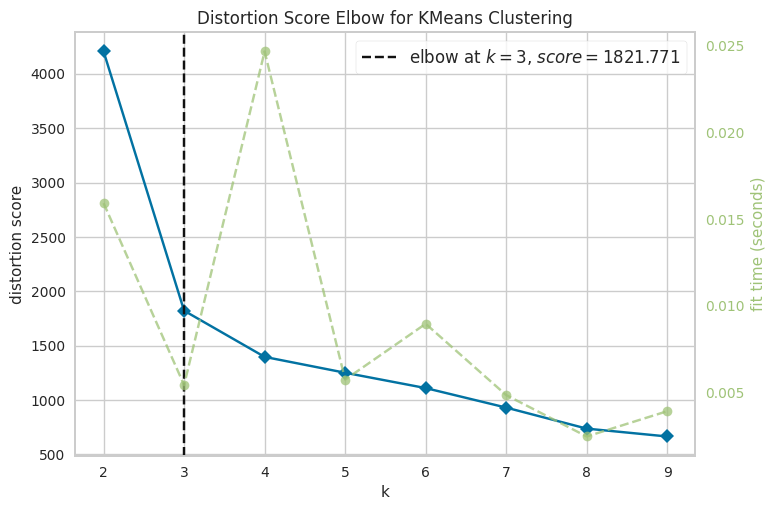

KElbowVisualizer(ax=<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>,
                 estimator=KMeans(n_clusters=9, n_init='auto', random_state=42),
                 k=(2, 10))

In [4]:
kelbow_visualizer(KMeans(n_init='auto', random_state=42), X, k=(2,10))

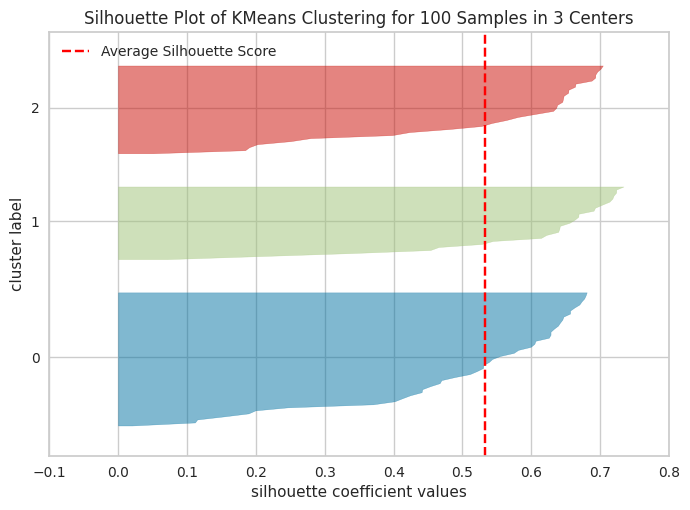

SilhouetteVisualizer(ax=<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 100 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>,
                     colors='yellowbrick',
                     estimator=KMeans(n_clusters=3, n_init='auto',
                                      random_state=42))

In [5]:
silhouette_visualizer(KMeans(3, n_init='auto', random_state=42), X, colors='yellowbrick')